In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
df = pd.read_csv("cyber security data.csv")

df.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [3]:
label_counts = df["label"].value_counts().sort_index()

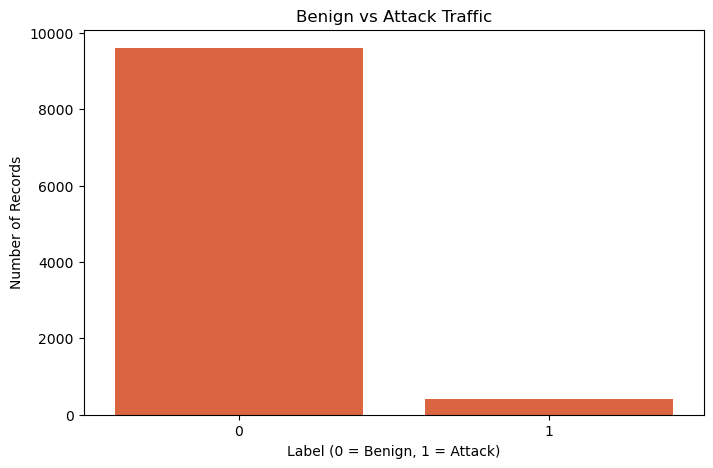

In [4]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    color="#F55727")
plt.title("Benign vs Attack Traffic")
plt.xlabel("Label (0 = Benign, 1 = Attack)")
plt.ylabel("Number of Records")
plt.savefig("01_benign_vs_attack.png", dpi=300, bbox_inches="tight")
plt.show()

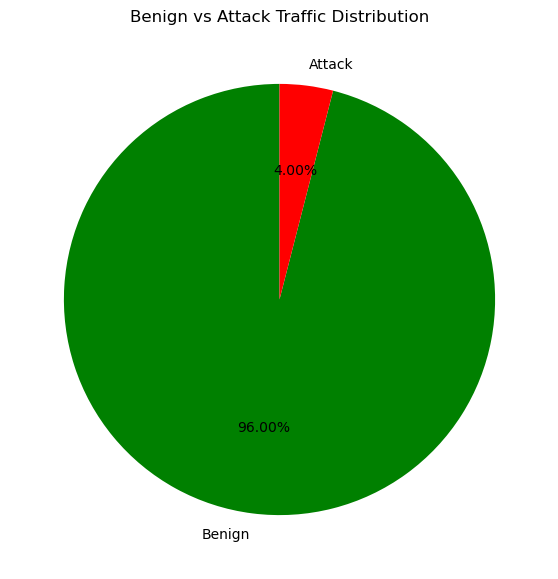

In [5]:
plt.figure(figsize=(7, 7))
plt.pie(
    label_counts.values,
    labels=["Benign", "Attack"],
    autopct="%1.2f%%",
    startangle=90,
    colors=["green", "red"]    
)
plt.title("Benign vs Attack Traffic Distribution")
plt.savefig("02_benign_vs_attack_pie.png", dpi=300, bbox_inches="tight")
plt.show()

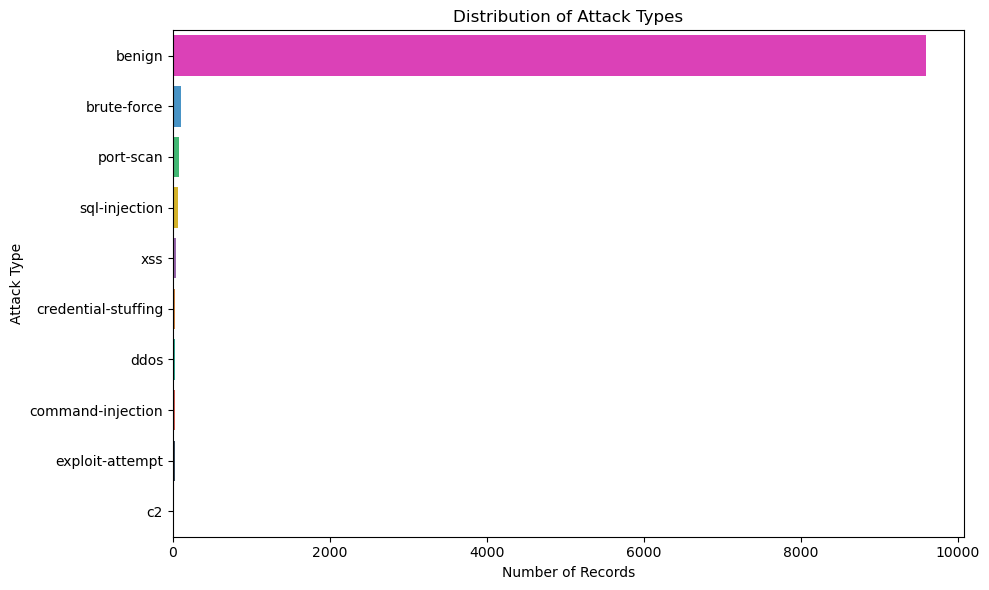

In [6]:
attack_counts = df["attack_type"].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(
    x=attack_counts.values,
    y=attack_counts.index,
    palette=["#F527C5","#3498DB","#2ECC71","#F1C40F","#9B59B6","#E67E22","#1ABC9C","#E74C3C","#34495E","#95A5A6"],
    hue=attack_counts.index,
    legend=False)
plt.title("Distribution of Attack Types")
plt.xlabel("Number of Records")
plt.ylabel("Attack Type")
plt.tight_layout()
plt.savefig("03_attack_type_distribution.png",dpi=300,bbox_inches="tight")
plt.show()

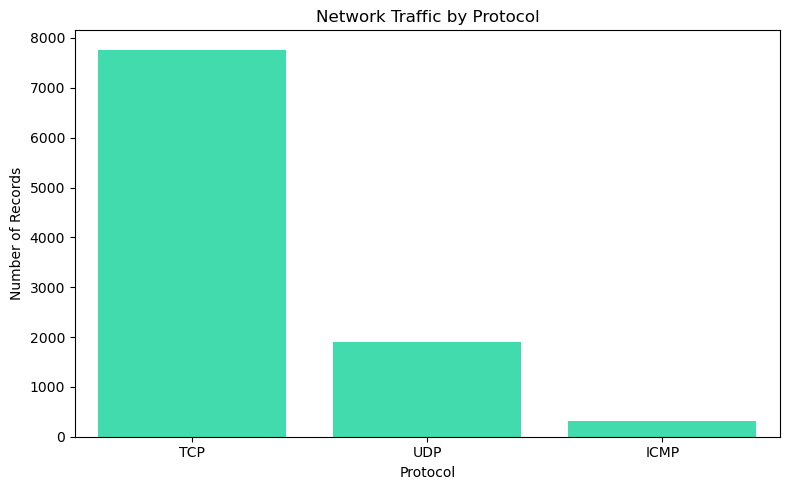

In [7]:
protocol_counts = df["protocol"].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(
    x=protocol_counts.index,
    y=protocol_counts.values,
    color="#27F5B7"
)
plt.title("Network Traffic by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig("04_protocol_distribution.png",dpi=300,bbox_inches="tight")
plt.show()

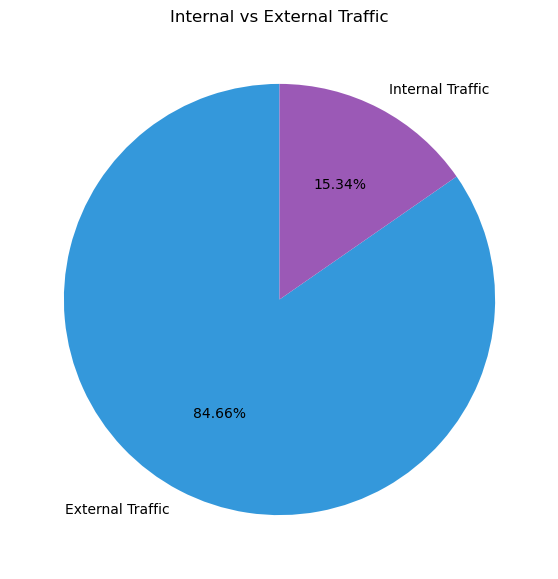

In [8]:
internal_counts = df["is_internal_traffic"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(
    internal_counts.values,
    labels=["External Traffic", "Internal Traffic"],
    autopct="%1.2f%%",
    startangle=90,
    colors=["#3498DB", "#9B59B6"]
)
plt.title("Internal vs External Traffic")
plt.savefig("05_internal_vs_external.png",dpi=300,bbox_inches="tight"
)
plt.show()

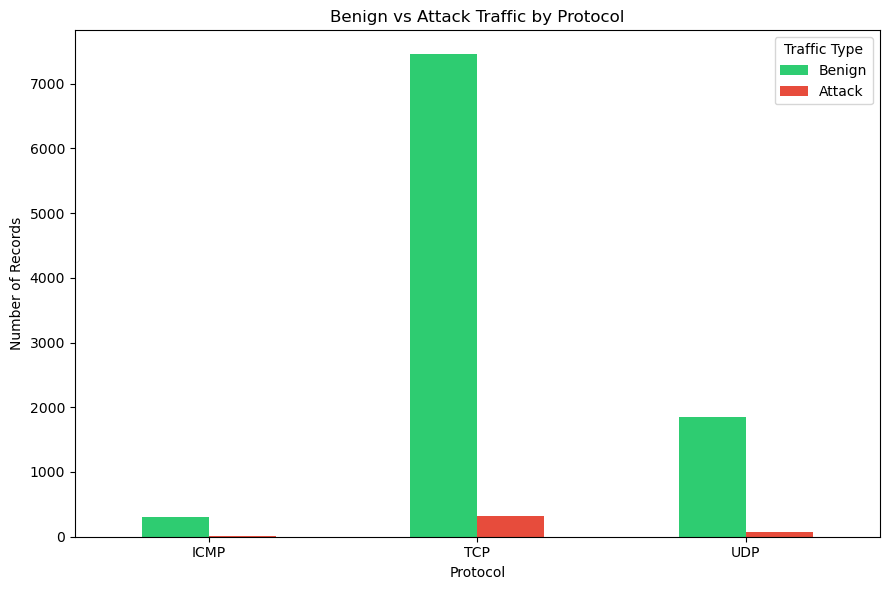

In [9]:
protocol_attack = pd.crosstab(
    df["protocol"],
    df["label"]
)
protocol_attack.columns = ["Benign", "Attack"]
ax = protocol_attack.plot(
    kind="bar",
    figsize=(9, 6),
    color=["#2ECC71", "#E74C3C"]
)
plt.title("Benign vs Attack Traffic by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Traffic Type")
plt.tight_layout()
plt.savefig("06_attack_by_protocol.png",dpi=300,bbox_inches="tight"
)
plt.show()

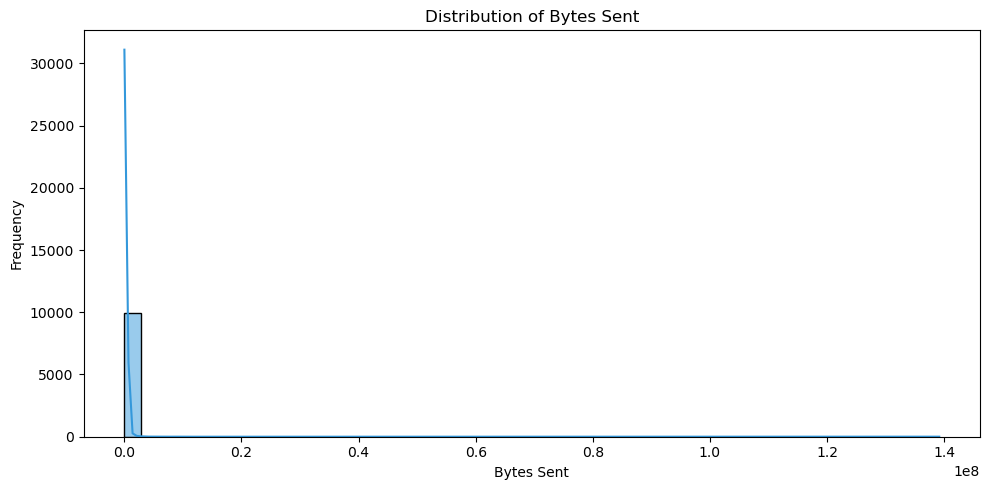

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="bytes_sent",
    bins=50,
    color="#3498DB",
    kde=True
)
plt.title("Distribution of Bytes Sent")
plt.xlabel("Bytes Sent")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("07_bytes_sent_distribution.png",dpi=300,bbox_inches="tight"
)
plt.show()

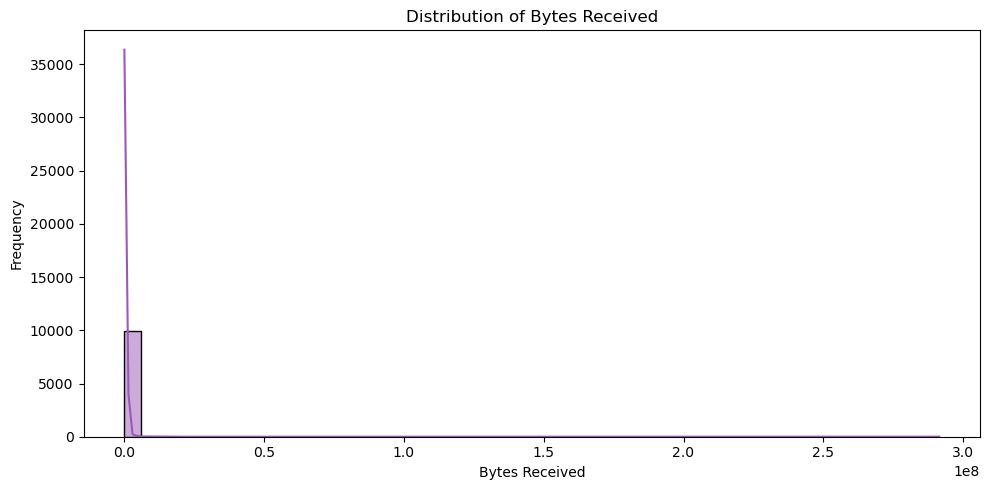

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="bytes_received",
    bins=50,
    color="#9B59B6",
    kde=True
)
plt.title("Distribution of Bytes Received")
plt.xlabel("Bytes Received")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("08_bytes_received_distribution.png",dpi=300,bbox_inches="tight"
)
plt.show()

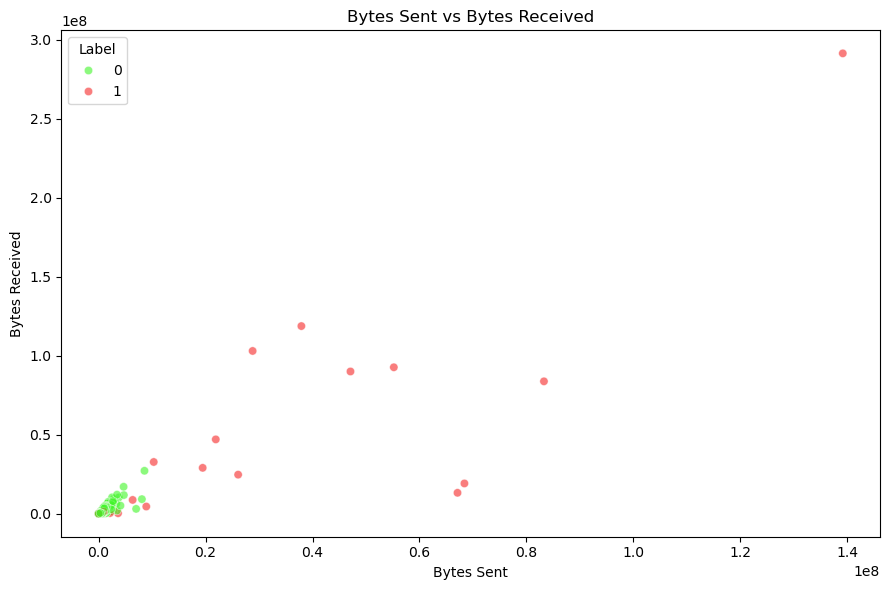

In [12]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="bytes_sent",
    y="bytes_received",
    hue="label",
    palette={
        0: "#3FF527",
        1: "#F52727"
    },
    alpha=0.6
)
plt.title("Bytes Sent vs Bytes Received")
plt.xlabel("Bytes Sent")
plt.ylabel("Bytes Received")
plt.legend(title="Label")
plt.tight_layout()
plt.savefig("09_bytes_sent_vs_received.png",dpi=300,bbox_inches="tight"
)
plt.show()

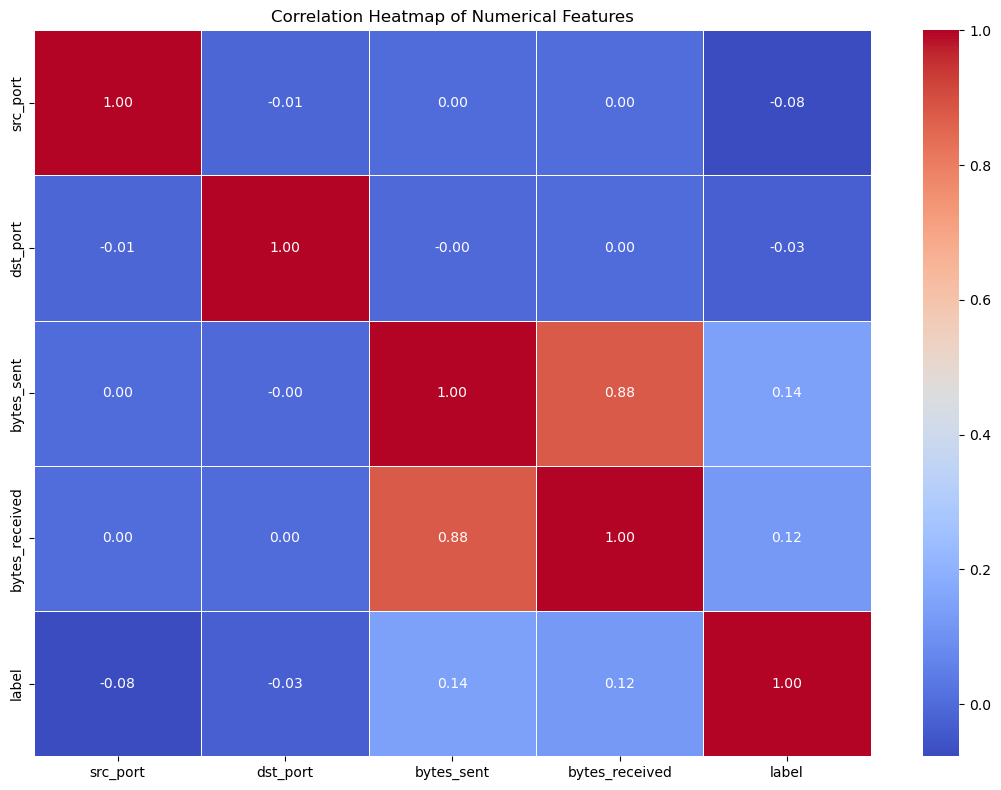

In [13]:
numeric_df = df.select_dtypes(include="number")
plt.figure(figsize=(11, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("10_correlation_heatmap.png",dpi=300,bbox_inches="tight"
)
plt.show()